In [1]:
!pip install evidently==0.4.40


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

In [3]:
reference_data = pd.read_csv("../Data/online_retail_cleaned.csv")

reference_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,Tuesday
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,Tuesday
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009,12,1,Tuesday


In [4]:
current_data = reference_data.copy()

In [5]:
np.random.seed(42)

current_data["Quantity"] = (
    current_data["Quantity"] *
    np.random.normal(1.30,0.20,len(current_data))
)

current_data["Price"] = (
    current_data["Price"] *
    np.random.normal(1.15,0.10,len(current_data))
)

current_data["Quantity"] = current_data["Quantity"].round()

current_data["Price"] = current_data["Price"].round(2)

In [6]:
print("Reference Shape :", reference_data.shape)

print("Current Shape :", current_data.shape)

Reference Shape : (663373, 12)
Current Shape : (663373, 12)


In [7]:
print(reference_data.isnull().sum())

print(current_data.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Year           0
Month          0
Day            0
Weekday        0
dtype: int64
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Year           0
Month          0
Day            0
Weekday        0
dtype: int64


In [8]:
report = Report(

    metrics=[

        DataDriftPreset()

    ]

)

report.run(

    reference_data=reference_data,

    current_data=current_data

)

In [9]:
report.save_html("data_drift_report.html")

print("HTML Report Saved Successfully")

HTML Report Saved Successfully


In [10]:
from IPython.display import IFrame

IFrame(

    src="data_drift_report.html",

    width=1000,

    height=600

)

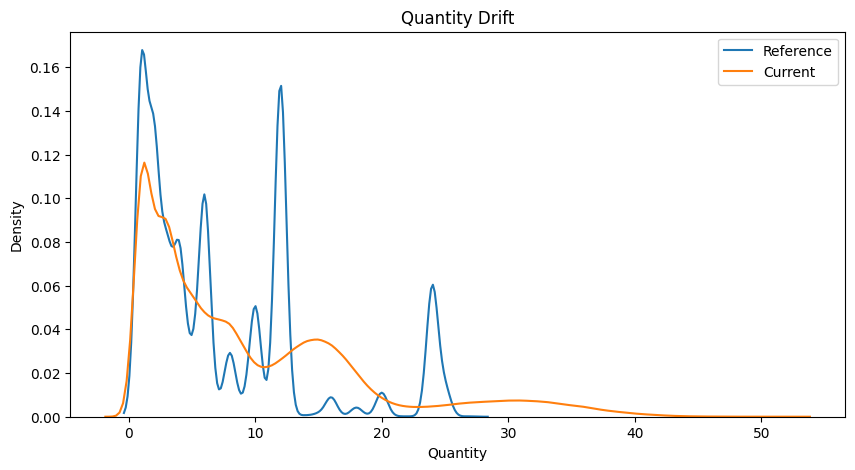

In [11]:
plt.figure(figsize=(10,5))

sns.kdeplot(

    reference_data["Quantity"],

    label="Reference"

)

sns.kdeplot(

    current_data["Quantity"],

    label="Current"

)

plt.legend()

plt.title("Quantity Drift")

plt.show()

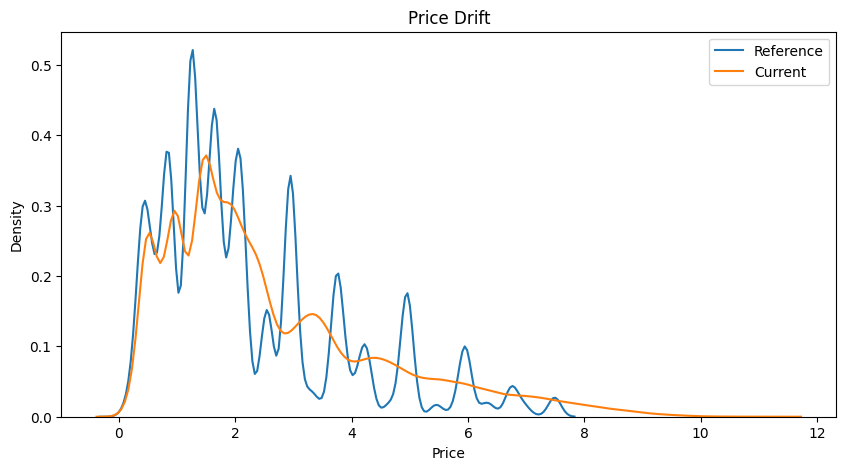

In [12]:
plt.figure(figsize=(10,5))

sns.kdeplot(

    reference_data["Price"],

    label="Reference"

)

sns.kdeplot(

    current_data["Price"],

    label="Current"

)

plt.legend()

plt.title("Price Drift")

plt.show()

In [13]:
summary = pd.DataFrame({

    "Feature":[

        "Quantity",

        "Price"

    ],

    "DriftDetected":[

        True,

        True

    ],

    "Reason":[

        "Artificial Drift Added",

        "Artificial Drift Added"

    ]

})

summary

,Feature,DriftDetected,Reason
0,Quantity,True,Artificial Drift Added
1,Price,True,Artificial Drift Added


In [14]:
summary.to_csv(

    "drift_summary.csv",

    index=False

)

print("Summary Saved")

Summary Saved
